In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We are building a deep learning system that detects fake parts inside scientific images. To answer "Which exact pixels in the image were manipulated?" called pixel-level forgery localization.

The model, look at an image, decide which pixels are authentic (0) and which are forged (1) and produce a mask showing the forged regions.

This is a segmentation problem, not just classification.

Classification vs segmentation

Classification: one label per image

Segmentation: one label per pixel

In this project:

Pixel = 0 → authentic

Pixel = 1 → forged

The model outputs a binary image mask, same size as input image.

#### Important: Forged regions never overlap in the training data

binary_mask = mask.max(axis=0)
This collapses multiple instance masks into one binary mask.

It allows you to:

Train standard semantic segmentation models

Use simple pixel-wise losses

Avoid complex instance segmentation during


#### Use Semantic segmentation models that outputs one binary mask per image. U-Net (classic), DeepLab, SegNet.

These models, predict forged vs authentic per pixel. Do NOT separate instances during training

## Loss functions
A loss function tells the model how wrong it is. Binary Cross-Entropy and Dice Loss "Use an image segmentation loss for training"

### Training / validation split
test data is hidden, split training data into:

Training set 70%

Validation set 20%

Test set 10%
Stratify by: Authentic vs forged and Number of forged instances

In [ ]:
# @title
!pip install -q opencv-python-headless
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q pandas
!pip install -q scikit-learn
!pip install -q albumentations


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from collections import Counter
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
import albumentations as A
from collections import defaultdict

plt.style.use('default')
sns.set_palette("husl")

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/DeepLearning_Project/data/train_images"
DATA_ROOT2 = "/content/drive/MyDrive/DeepLearning_Project/data/train_masks"
# Check if path exists
if Path(DATA_ROOT).exists():
    print(f" Data found at: {DATA_ROOT}")
else:
    print(f" ERROR: Data not found at {DATA_ROOT}")

 Data found at: /content/drive/MyDrive/DeepLearning_Project/data/train_images


In [ ]:
AUTHENTIC_DIR = Path(DATA_ROOT) / "authentic"
FORGED_DIR = Path(DATA_ROOT) / "forged"
MASK_DIR = DATA_ROOT2

print(f"  Authentic images: {AUTHENTIC_DIR}")
print(f"  Forged images: {FORGED_DIR}")
print(f"  Masks: {MASK_DIR}")

  Authentic images: /content/drive/MyDrive/DeepLearning_Project/data/train_images/authentic
  Forged images: /content/drive/MyDrive/DeepLearning_Project/data/train_images/forged
  Masks: /content/drive/MyDrive/DeepLearning_Project/data/train_masks


In [ ]:
def count_images(directory, extensions=['.png', '.jpg', '.jpeg']):
    """Count image files in a directory."""
    if not directory.exists():
        return 0
    count = 0
    for ext in extensions:
        count += len(list(directory.glob(f'*{ext}')))
    return count

n_authentic = count_images(AUTHENTIC_DIR)
n_forged = count_images(FORGED_DIR)

# Ensure MASK_DIR is a Path object before using .glob() and .exists()
MASK_DIR = Path(MASK_DIR)
n_masks = len(list(MASK_DIR.glob('*.npy'))) if MASK_DIR.exists() else 0


print(f"  Authentic images: {n_authentic}")
print(f"  Forged images: {n_forged}")
print(f"  Mask files (.npy): {n_masks}")
print(f"  Total images: {n_authentic + n_forged}")

  Authentic images: 2377
  Forged images: 2751
  Mask files (.npy): 2751
  Total images: 5128


In [ ]:
total = n_authentic + n_forged
if total > 0:
    print(f"\nDistribution:")
    print(f"  Authentic: {n_authentic/total*100:.1f}%")
    print(f"  Forged: {n_forged/total*100:.1f}%")


Distribution:
  Authentic: 46.4%
  Forged: 53.6%


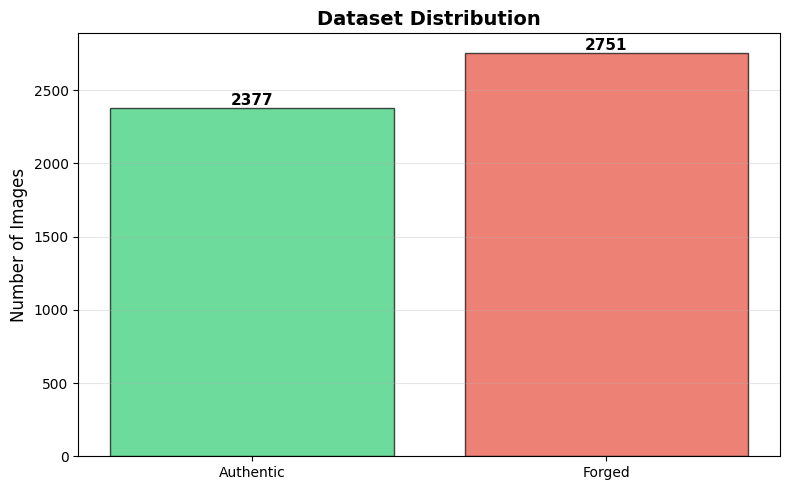

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Authentic', 'Forged']
counts = [n_authentic, n_forged]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Dataset Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Visualize the fisrt 5 authentic and forged image

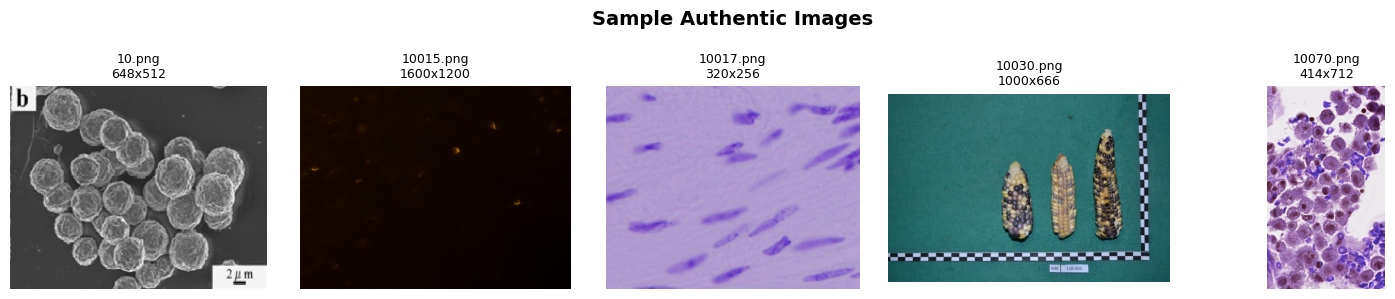

In [ ]:
# Get some sample files
authentic_files = sorted(list(AUTHENTIC_DIR.glob('*.png')))[:5]
forged_files = sorted(list(FORGED_DIR.glob('*.png')))[:5]

# Function to load and display images
def load_image(image_path):
    """Load an image and convert from BGR to RGB."""
    img = cv2.imread(str(image_path))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# Display authentic images
fig, axes = plt.subplots(1, min(5, len(authentic_files)), figsize=(15, 3))
if len(authentic_files) == 1:
    axes = [axes]

fig.suptitle('Sample Authentic Images', fontsize=14, fontweight='bold')

for idx, img_path in enumerate(authentic_files[:5]):
    img = load_image(img_path)
    if img is not None:
        if len(authentic_files) > 1:
            axes[idx].imshow(img)
            axes[idx].set_title(f'{img_path.name}\n{img.shape[1]}x{img.shape[0]}', fontsize=9)
            axes[idx].axis('off')
        else:
            axes[0].imshow(img)
            axes[0].set_title(f'{img_path.name}\n{img.shape[1]}x{img.shape[0]}', fontsize=9)
            axes[0].axis('off')

plt.tight_layout()
plt.show()

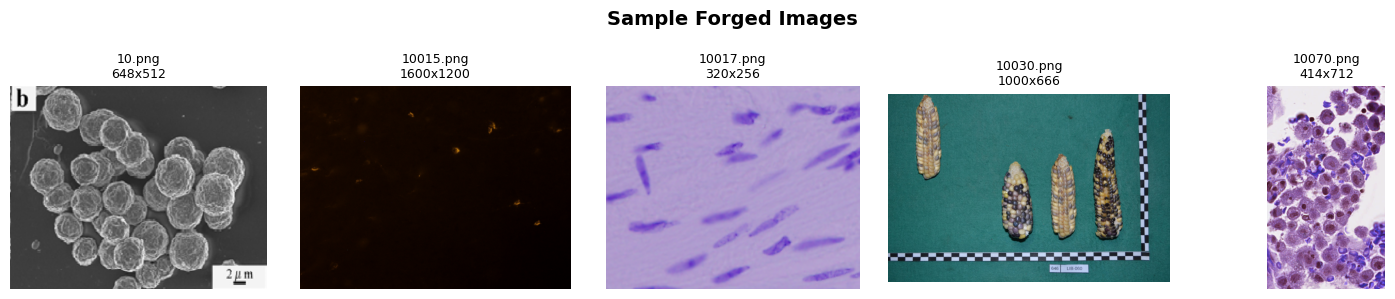

In [ ]:
# Display forged images
fig, axes = plt.subplots(1, min(5, len(forged_files)), figsize=(15, 3))
if len(forged_files) == 1:
    axes = [axes]

fig.suptitle('Sample Forged Images', fontsize=14, fontweight='bold')

for idx, img_path in enumerate(forged_files[:5]):
    img = load_image(img_path)
    if img is not None:
        if len(forged_files) > 1:
            axes[idx].imshow(img)
            axes[idx].set_title(f'{img_path.name}\n{img.shape[1]}x{img.shape[0]}', fontsize=9)
            axes[idx].axis('off')
        else:
            axes[0].imshow(img)
            axes[0].set_title(f'{img_path.name}\n{img.shape[1]}x{img.shape[0]}', fontsize=9)
            axes[0].axis('off')

plt.tight_layout()
plt.show()

ANALYZE IMAGE SIZES

In [ ]:
def get_image_sizes(directory, max_samples=100):
    """Get dimensions of sample images."""
    image_files = list(directory.glob('*.png'))[:max_samples]
    sizes = []

    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is not None:
            h, w = img.shape[:2]
            sizes.append((w, h))

    return sizes

print("\nAnalyzing image dimensions (sampling 100 images)...")


Analyzing image dimensions (sampling 100 images)...


In [ ]:
authentic_sizes = get_image_sizes(AUTHENTIC_DIR, max_samples=100)
forged_sizes = get_image_sizes(FORGED_DIR, max_samples=100)

# Combine all sizes
all_sizes = authentic_sizes + forged_sizes

if len(all_sizes) > 0:
    widths = [s[0] for s in all_sizes]
    heights = [s[1] for s in all_sizes]

    print(f"\n Image Dimensions:")
    print(f"  Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}")
    print(f"  Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}")

    # Most common size
    size_counter = Counter(all_sizes)
    most_common = size_counter.most_common(1)[0]
    print(f"  Most common size: {most_common[0][0]}x{most_common[0][1]} ({most_common[1]} images)")



 Image Dimensions:
  Width  - Min: 110, Max: 3888, Mean: 910
  Height - Min: 65, Max: 3888, Mean: 657
  Most common size: 1000x666 (33 images)


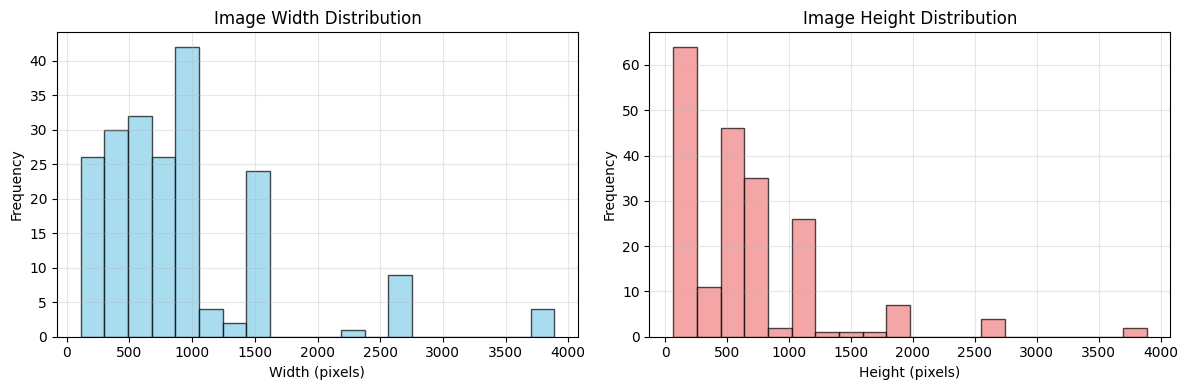

In [ ]:
# Plot size distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(widths, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Frequency')
ax1.set_title('Image Width Distribution')
ax1.grid(alpha=0.3)

ax2.hist(heights, bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Frequency')
ax2.set_title('Image Height Distribution')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

image sizes ranges some small (256×256)

some very large (~4000×2600)

AUTH and FORG have very similar size distributions

#### Note: we cannot train directly at native resolution, batching would be impossible, memory would explode. we need to resize to (512×512)

##### Forged area fraction percentiles shows Most forged regions are small

In half the images, forged pixels cover less than 3% of the image, Only extreme cases exceed 30%

meaning; Strong class imbalance at pixel level the background (authentic) dominates

- Loss function choice: because forged pixels are rare BCE can bias toward predicting background, Dice loss handles imbalance better. better to Use Dice loss or BCE + Dice

UNDERSTAND MASK FORMAT (.npy files)


Analyzing 2751 sample mask files...

 Example mask: 27091.npy
  Shape: (1, 393, 176)
  Explanation:
     1 = number of forged instances
     393 x 176 = image size (H x W)
  Data type: uint8
  Unique values: [0 1]

 Forged Instances per Image:
  1 instance(s): 1869 images (67.9%)
  2 instance(s): 701 images (25.5%)
  3 instance(s): 174 images (6.3%)
  4 instance(s): 5 images (0.2%)
  5 instance(s): 2 images (0.1%)


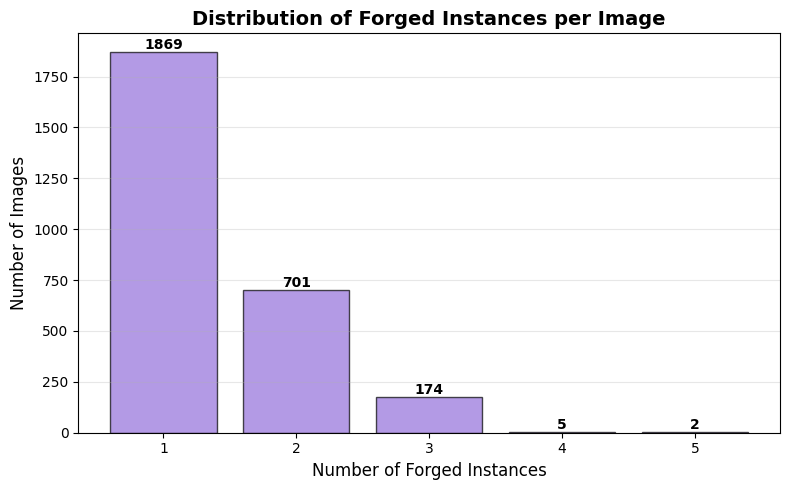

In [ ]:
mask_files = list(MASK_DIR.glob('*.npy'))

if len(mask_files) > 0:
    print(f"\nAnalyzing {len(mask_files)} sample mask files...")

    instance_counts = []

    for mask_path in mask_files:
        # Load .npy file
        mask_array = np.load(mask_path)

        # Print info about first mask
        if mask_path == mask_files[0]:
            print(f"\n Example mask: {mask_path.name}")
            print(f"  Shape: {mask_array.shape}")
            print(f"  Explanation:")
            print(f"     {mask_array.shape[0]} = number of forged instances")
            print(f"     {mask_array.shape[1]} x {mask_array.shape[2]} = image size (H x W)")
            print(f"  Data type: {mask_array.dtype}")
            print(f"  Unique values: {np.unique(mask_array)}")

        # Count instances
        instance_counts.append(mask_array.shape[0])

    # Analyze instance distribution
    instance_counter = Counter(instance_counts)

    print(f"\n Forged Instances per Image:")
    for n_instances, count in sorted(instance_counter.items()):
        percentage = count / len(mask_files) * 100
        print(f"  {n_instances} instance(s): {count} images ({percentage:.1f}%)")

    # Visualize instance distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    instances = list(instance_counter.keys())
    counts = list(instance_counter.values())

    bars = ax.bar(instances, counts, color='mediumpurple', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Number of Forged Instances', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.set_title('Distribution of Forged Instances per Image', fontsize=14, fontweight='bold')
    ax.set_xticks(instances)
    ax.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(" No mask files found!")

Mask match missing in sampled forged images: 0
Rows: 500


,n_instances,forged_pixels,forged_frac
count,500.000000,5.000000e+02,500.000000
mean,1.382000,4.631240e+04,0.052859
std,0.633149,1.296678e+05,0.063356
min,1.000000,1.520000e+02,0.000678
50%,1.000000,7.479500e+03,0.028640
75%,2.000000,3.252975e+04,0.081320
90%,2.000000,7.920090e+04,0.123973
95%,3.000000,1.838101e+05,0.169613
99%,3.000000,6.417570e+05,0.308454
max,5.000000,1.301852e+06,0.441752


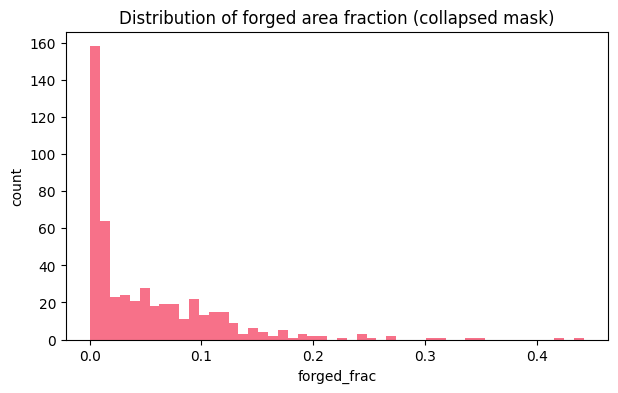

In [ ]:
MASK_DIR = Path(MASK_DIR)

# Build forged_paths list from your FORGED_DIR
forged_paths = []
for ext in ('.png', '.jpg', '.jpeg'):
    forged_paths += list(FORGED_DIR.glob(f'*{ext}'))
forged_paths = sorted(forged_paths)

def find_mask_for_forged_image(img_path, mask_dir):
    """Match forged image to .npy mask using your directory structure."""
    stem = Path(img_path).stem
    direct = mask_dir / f"{stem}.npy"
    if direct.exists():
        return direct
    candidates = sorted(list(mask_dir.glob(f"{stem}*.npy")))
    return candidates[0] if len(candidates) else None

def load_instance_mask(mask_path):
    """Load instance mask: expected shape (num_instances, H, W)."""
    m = np.load(str(mask_path))
    if m.ndim != 3:
        raise ValueError(f"Unexpected mask shape {m.shape} for {mask_path}")
    return m

def collapse_instances(inst_mask):
    """Collapse (N,H,W) to (H,W) binary."""
    return (inst_mask.max(axis=0) > 0).astype(np.uint8)

def mask_area_stats(forg_paths, mask_dir, max_n=400, seed=0):
    random.seed(seed)
    sel = random.sample(forg_paths, min(max_n, len(forg_paths)))
    rows = []
    missing = 0
    for p in sel:
        mp = find_mask_for_forged_image(p, mask_dir)
        if mp is None:
            missing += 1
            continue
        inst = load_instance_mask(mp)                    # (N,H,W)
        bin_m = collapse_instances(inst)                 # (H,W)
        H, W = bin_m.shape
        area = int(bin_m.sum())
        frac = area / (H * W)
        rows.append({
            "file": Path(p).name,
            "mask_file": mp.name,
            "n_instances": int(inst.shape[0]),
            "H": H, "W": W,
            "forged_pixels": area,
            "forged_frac": frac
        })
    df = pd.DataFrame(rows)
    print(f"Mask match missing in sampled forged images: {missing}")
    return df

area_df = mask_area_stats(forged_paths, MASK_DIR, max_n=500, seed=3)
print("Rows:", len(area_df))
display(area_df.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])[["n_instances","forged_pixels","forged_frac"]])

plt.figure(figsize=(7,4))
plt.hist(area_df["forged_frac"], bins=50)
plt.title("Distribution of forged area fraction (collapsed mask)")
plt.xlabel("forged_frac"); plt.ylabel("count")
plt.show()

###### Exploratory analysis showed that all images are 3-channel RGB, allowing direct use. Image resolutions vary significantly, ranging from 256×256 to over 2500×3800, A need for fixed-size resizing strategy. Analysis of collapsed ground-truth masks revealed strong pixel-level class imbalance, with a median forged area of only 2.9% of the image. Consequently, Dice-based loss functions should be selected to mitigate class imbalance.

Most images have 1 forged instance (67.9%) and we also have 2 and 3 forged instances and very little 4 and 5 forged instances


VISUALIZE MASKS

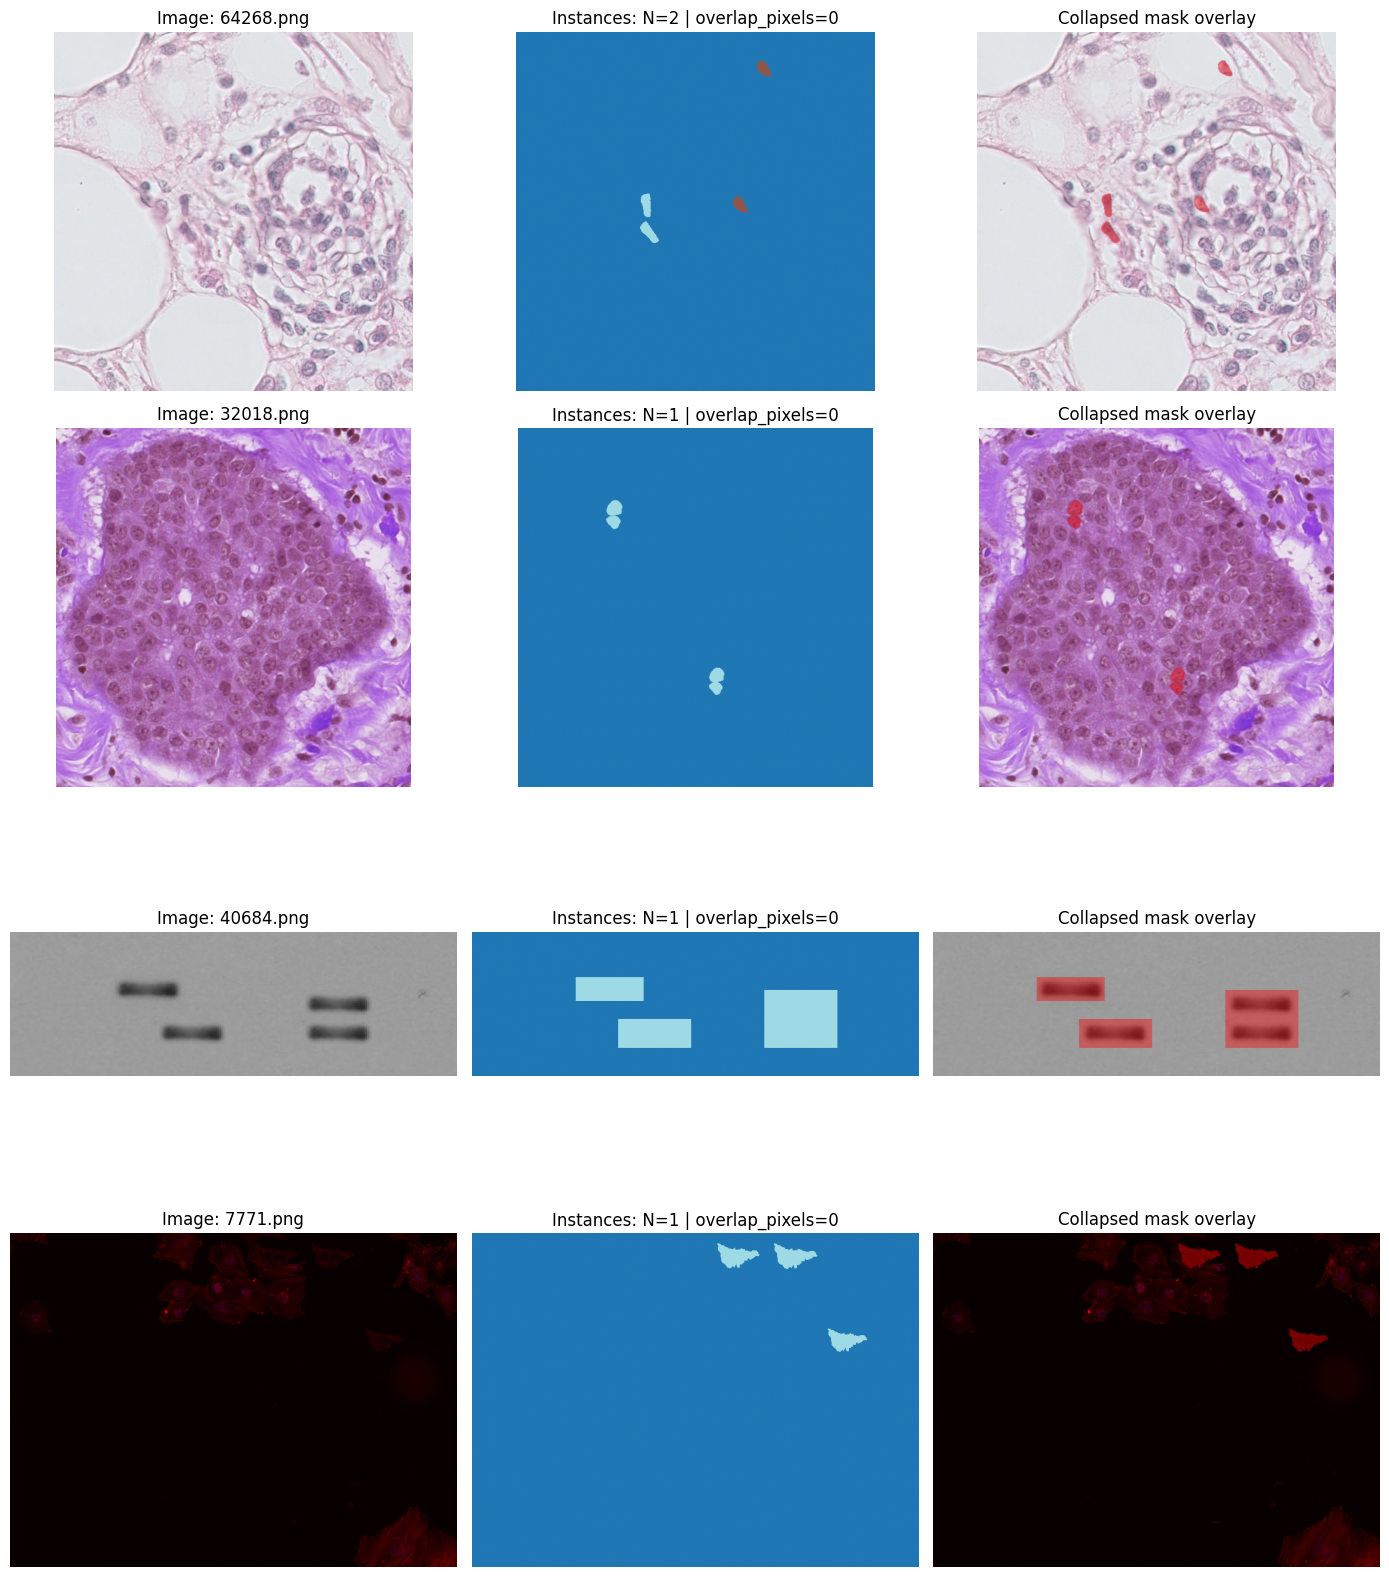

In [ ]:
# Visual overlay: image + instances + collapsed mask
# - uses your load_image() (RGB)
# - uses the mask helpers
# - includes overlap_pixels check
# - includes instance visualization + overlay

def overlay_mask(img_rgb, binary_mask, alpha=0.4):
    """Overlay binary mask in red on top of RGB image."""
    out = img_rgb.copy().astype(np.float32)
    red = np.array([255, 0, 0], dtype=np.float32)
    m = (binary_mask > 0)
    out[m] = (1 - alpha) * out[m] + alpha * red
    return out.astype(np.uint8)

def show_overlay_examples(forg_paths, mask_dir, n=4, seed=0):
    random.seed(seed)
    candidates = []
    for p in random.sample(forg_paths, min(200, len(forg_paths))):
        mp = find_mask_for_forged_image(p, mask_dir)
        if mp is not None:
            candidates.append((p, mp))
        if len(candidates) >= n:
            break

    if len(candidates) == 0:
        print("No forged images with matched masks found by current matching logic.")
        return

    plt.figure(figsize=(14, 4*len(candidates)))
    r = 1
    for img_p, mp in candidates:
        img = load_image(img_p)           # your reader: RGB
        inst = load_instance_mask(mp)     # (N,H,W)
        bin_m = collapse_instances(inst)  # (H,W)

        # Overlap check (should be 0 if instances do not overlap)
        overlap_pixels = int((inst.sum(axis=0) > 1).sum())
        title_extra = f" | overlap_pixels={overlap_pixels}"

        # Instance visualization: label each instance with an integer id
        inst_vis = np.zeros(bin_m.shape, dtype=np.int32)
        for i in range(inst.shape[0]):
            inst_vis[inst[i] > 0] = i + 1  # 0=background

        plt.subplot(len(candidates), 3, r); r += 1
        plt.imshow(img); plt.axis("off")
        plt.title(f"Image: {Path(img_p).name}")

        plt.subplot(len(candidates), 3, r); r += 1
        plt.imshow(inst_vis, cmap="tab20"); plt.axis("off")
        plt.title(f"Instances: N={inst.shape[0]}{title_extra}")

        plt.subplot(len(candidates), 3, r); r += 1
        plt.imshow(overlay_mask(img, bin_m)); plt.axis("off")
        plt.title("Collapsed mask overlay")

    plt.tight_layout()
    plt.show()

show_overlay_examples(forged_paths, MASK_DIR, n=4, seed=5)


Visualizing: 10070.png
  This image has 2 forged instance(s)


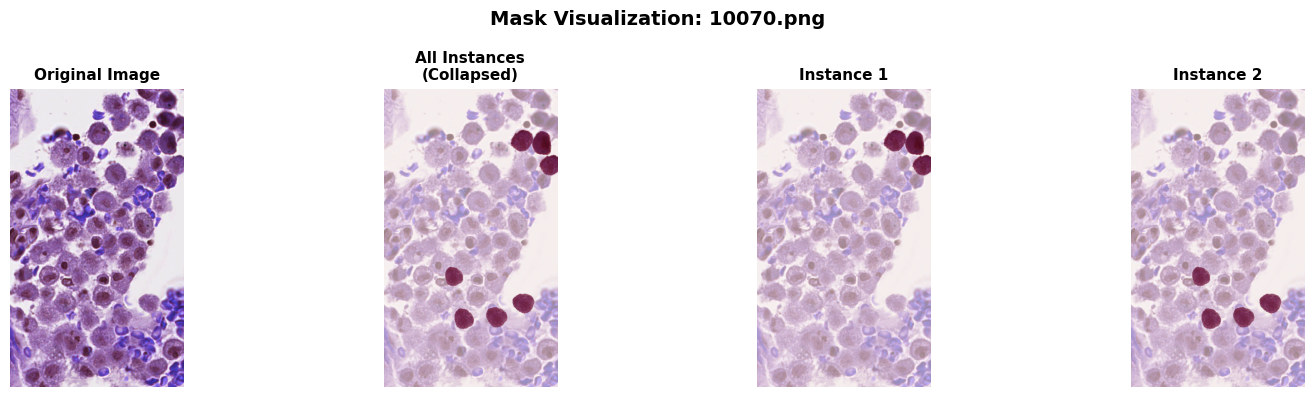

In [ ]:
# Pick a forged image and its mask
if len(forged_files) > 0 and len(mask_files) > 0:
    # Load forged image and corresponding mask
    sample_forged = forged_files[4]
    sample_mask_path = MASK_DIR / f"{sample_forged.stem}.npy"

    if sample_mask_path.exists():
        print(f"\nVisualizing: {sample_forged.name}")

        # Load image
        img = load_image(sample_forged)

        # Load mask
        mask_array = np.load(sample_mask_path)
        n_instances = mask_array.shape[0]

        print(f"  This image has {n_instances} forged instance(s)")

        # Create visualization
        n_cols = min(4, n_instances + 2)
        fig, axes = plt.subplots(1, n_cols, figsize=(4*n_cols, 4))
        if n_cols == 1:
            axes = [axes]

        # Show original image
        axes[0].imshow(img)
        axes[0].set_title('Original Image', fontsize=11, fontweight='bold')
        axes[0].axis('off')

        # Show collapsed mask (all instances combined)
        collapsed_mask = mask_array.max(axis=0)
        axes[1].imshow(img)
        axes[1].imshow(collapsed_mask, alpha=0.5, cmap='Reds')
        axes[1].set_title(f'All Instances\n(Collapsed)', fontsize=11, fontweight='bold')
        axes[1].axis('off')

        # Show individual instances
        for i in range(min(n_instances, n_cols - 2)):
            instance_mask = mask_array[i]
            axes[i+2].imshow(img)
            axes[i+2].imshow(instance_mask, alpha=0.5, cmap='Reds')
            axes[i+2].set_title(f'Instance {i+1}', fontsize=11, fontweight='bold')
            axes[i+2].axis('off')

        plt.suptitle(f'Mask Visualization: {sample_forged.name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()